# Calibrating the detector — do this before anything else

**Audience:** you are about to analyse diffraction data and you do not yet have
`Lsd`, the beam centre, the tilts or the distortion. **No prior MIDAS
experience assumed.**

Notebook `01` asks you to type those numbers into its configuration cell. This
notebook is where they come from.

### Why it comes first

Every radius you measure becomes a d-spacing through the geometry:

```
R (pixels) --> 2θ = atan(R · pixel_size / Lsd) --> d = λ / (2 sin θ)
```

Get `Lsd` wrong by 1% and every d-spacing is wrong by ~1% — about 10 000 µε of
spurious strain, which is 100× a real elastic strain. Get the beam centre wrong
and the rings stop being concentric, so a single ring gives a different
d-spacing at every azimuth. **No amount of careful reconstruction downstream
recovers from an uncalibrated detector.**

### What you need

| | |
|---|---|
| a **calibrant** exposure | a powder of known lattice parameter: CeO₂, LaB₆, Si or Al₂O₃ |
| a **dark** | same exposure time, no beam |
| the **wavelength** | from the monochromator, in Å |
| the **pixel size** | from the detector datasheet, in µm |
| a rough **distance** | to a few cm is plenty — this gets refined |

You do **not** need the beam centre. Finding it is the calibration's job, and
§3 shows what happens when you guess.

### Scope

This notebook covers a **single area detector**. Multi-panel detectors (GE
1–4, HYDRA, stitched arrays) need per-panel refinement, which
`midas_calibrate_v2` supports through `panel_layout=` but which is not covered
here.

## 0 · Setup

In [1]:
%matplotlib inline
import sys, json, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

_here = Path.cwd()
for cand in (_here.parent, _here.parent.parent / "midas_tomo"):
    if cand.is_dir() and str(cand) not in sys.path:
        sys.path.insert(0, str(cand))
sys.path.insert(0, str(_here))

import midas_dt
print(f"midas-dt {midas_dt.__version__}")
try:
    from midas_calibrate_v2 import calibrate, CALIBRANTS
    print(f"midas-calibrate-v2: OK   calibrants: {sorted(CALIBRANTS)}")
except ImportError as exc:
    print(f"midas-calibrate-v2: MISSING -- {exc}\n"
          "  pip install midas-calibrate-v2")

midas-dt 0.4.0


midas-calibrate-v2: OK   calibrants: ['Al2O3', 'CeO2', 'LaB6', 'Si']


> ### ⚠️ macOS: calibration does not run here
>
> Measured on an Apple-silicon Mac with a conda MIDAS env: `calibrate()`
> **segfaults (SIGSEGV)** — and it segfaults *inside a child process too*, so
> this is not a Jupyter-state problem. It runs cleanly on Linux; the reference
> results in this notebook were produced there. The cause is the usual
> duplicate-OpenMP / libc++ collision, the same one that made
> `midas_pipeline` default its FBP to `backend="subprocess"`.
>
> `RUN_IN_SUBPROCESS` (§4) is therefore **damage control, not a fix**: it
> isolates the crash so you get a `RuntimeError` instead of a dead kernel, but
> the calibration still will not complete. **Run calibration on a Linux host.**
> Everything downstream — notebook `01` — is fine on macOS.


## 1 · Configure

In [2]:
# ============================ EDIT FROM HERE ============================

USE_DEMO_CALIBRANT = True   # True: synthesise a CeO2 frame with a KNOWN geometry
                            #       so you can watch it be recovered.
                            # False: use your own calibrant image below.

RUN_IN_SUBPROCESS = (sys.platform == "darwin")   # see the macOS warning above

OUT_DIR = Path("./calibration_output")

# ---- your calibrant exposure (ignored when USE_DEMO_CALIBRANT) ----------
CALIBRANT_FILE = Path("/path/to/CeO2_000123.tif")
DARK_FILE      = Path("/path/to/dark_000124.tif")

# ---- what the calibrant is ---------------------------------------------
CALIBRANT      = "CeO2"        # CeO2 | LaB6 | Si | Al2O3

# ---- instrument --------------------------------------------------------
WAVELENGTH_A   = 0.189714      # Angstroms. E[keV] = 12.3984 / lambda
PIXEL_UM       = 200.0         # detector pixel size, micrometres
INITIAL_LSD_UM = 950_000.0     # rough distance. A few cm out is fine.

# ---- what to refine ----------------------------------------------------
REFINE_TILTS      = True
REFINE_DISTORTION = True
MIN_RING_RADIUS_PX = 120.0     # ignore rings inside the beamstop
MAX_2THETA_DEG     = 28.0      # leave generous; rings off the detector are dropped

# ============================= EDIT TO HERE =============================

## 2 · The calibrant image

In demo mode this synthesises a CeO₂ pattern from a **known** geometry — a beam
centre deliberately off the detector centre — so §5 can score the calibration
against the truth instead of against "it looks about right".

The demo plants **no tilt**, on purpose. The obvious way to fake one,
`r → r(1 + tilt·cos η)`, is to first order *exactly a beam-centre shift*, so it
is degenerate with BC by construction and is not the projective deformation the
refiner actually models. Planting it left 174.8 µε and pushed BC 1.9 px off —
neither of which says anything about the calibration. Real tilts are real; that
is what the archived example in §7 is for.

synthetic CeO2: (2048, 2048), 21 rings on the detector
  PLANTED  Lsd 940086.0 um   BC (1037.50, 1014.50) px
  (detector centre is (1023.5, 1023.5) -- the beam is NOT there)

counts: min 5  median 33  max 3704


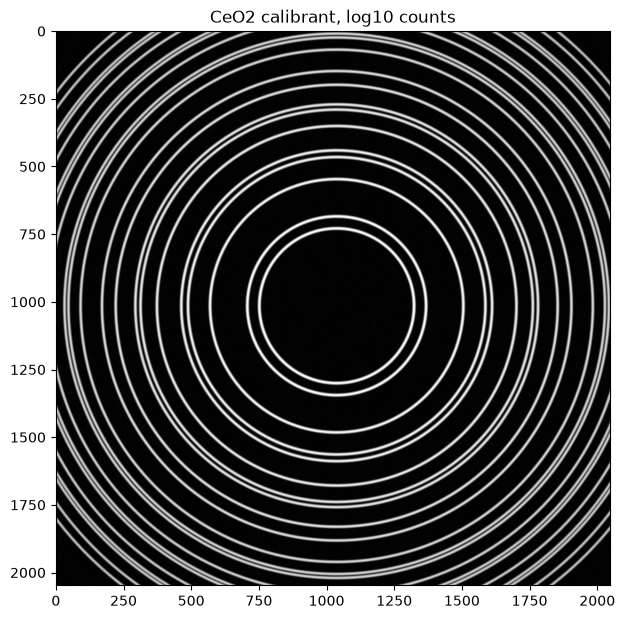

In [3]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

if USE_DEMO_CALIBRANT:
    from _demo import make_calibrant_frame
    frame, truth = make_calibrant_frame()
    print(f"synthetic {CALIBRANT}: {frame.shape}, {len(truth['rings'])} rings on the detector")
    print(f"  PLANTED  Lsd {truth['lsd_um']:.1f} um   "
          f"BC ({truth['bc_y_px']:.2f}, {truth['bc_z_px']:.2f}) px")
    print(f"  (detector centre is ({(frame.shape[1]-1)/2:.1f}, "
          f"{(frame.shape[0]-1)/2:.1f}) -- the beam is NOT there)")
    WAVELENGTH_A, PIXEL_UM = truth["wavelength_a"], truth["px_um"]
else:
    truth = None
    if not CALIBRANT_FILE.is_file():
        raise FileNotFoundError(
            f"{CALIBRANT_FILE} not found. Set USE_DEMO_CALIBRANT = True to run "
            f"the notebook on synthetic data.")
    try:
        import tifffile
        frame = tifffile.imread(CALIBRANT_FILE).astype(np.float64)
        if DARK_FILE.is_file():
            frame = np.clip(frame - tifffile.imread(DARK_FILE), 0, None)
    except ImportError:
        raise ImportError("reading TIFF needs `pip install tifffile`, or load "
                          "your detector's format into `frame` yourself")
    print(f"{CALIBRANT_FILE.name}: {frame.shape}")

print(f"\ncounts: min {frame.min():.0f}  median {np.median(frame):.0f}  "
      f"max {frame.max():.0f}")

disp = np.log10(np.clip(frame, 1.0, None))
fig, ax = plt.subplots(figsize=(7.2, 7.2))
ax.imshow(disp, cmap="gray", vmin=np.percentile(disp, 40),
          vmax=np.percentile(disp, 99.7))
ax.set_title(f"{CALIBRANT} calibrant, log10 counts")
fig.savefig(OUT_DIR / "calibrant.png", dpi=120, bbox_inches="tight")
plt.show()

## 3 · The one thing not to do: invent a beam centre

`calibrate()` has an auto-seeder that finds the beam centre and distance from
the rings themselves. It also accepts `BC_guess=`. **Passing a guess overrides
the seeder**, and if the guess is wrong the refinement cannot travel far enough
to recover.

Measured on one archived frame, same data and same code, only the guess
differing:

| | `BC_guess` = detector centre | seeder left alone |
|---|---|---|
| BC_z | 1022.6 — moved 0.9 px from the seed | **994.3** |
| Lsd | 948 323 µm | **940 055 µm** |
| residual strain | **1040 µε — FAIL** | **47 µε — PASS** |

The tell is not the residual, it is that **the refined values barely moved from
the seed**: BC_z travelled 0.9 px when it needed 29. A fit that sits where you
put it has not converged, whatever its residual says.

So: pass `initial_Lsd` (you genuinely know the distance to a few cm) and let BC
seed itself. Only supply a beam centre you actually measured.

Below is what a naive seed predicts — circles from the detector centre and a
guessed distance. They should visibly not sit on the rings.

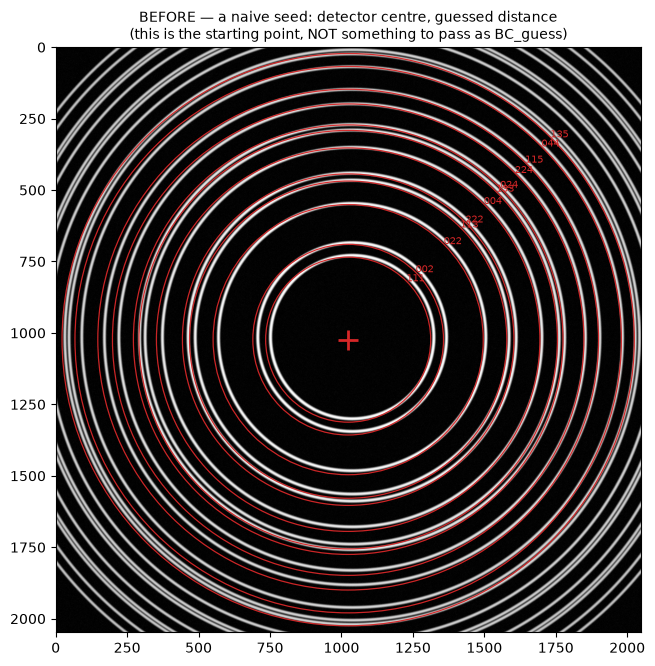

In [4]:
def ceo2_like_radii(lsd_um, px_um, lam_a, lattice_a=5.4116, n_max=12):
    """Ring radii in pixels for an fcc calibrant (h,k,l same parity)."""
    seen, out = set(), []
    for h in range(7):
        for k in range(7):
            for l in range(7):
                s = h*h + k*k + l*l
                if s == 0 or s in seen or not (h % 2 == k % 2 == l % 2):
                    continue
                seen.add(s)
                d = lattice_a / np.sqrt(s)
                arg = lam_a / (2*d)
                if arg >= 1:
                    continue
                out.append((s, lsd_um*np.tan(2*np.arcsin(arg))/px_um, (h,k,l)))
    out.sort()
    return [(r, hkl) for _, r, hkl in out[:n_max]]


def ring_overlay(img, bc_y, bc_z, radii, title, path, labels=None):
    """Rings on the image. The standing rule: a strain number tells you a
    calibration failed, the overlay tells you WHY -- wrong Lsd (circles too
    big or small), off centre (not concentric), wrong transform (sheared)."""
    d = np.log10(np.clip(img, 1.0, None))
    fig, ax = plt.subplots(figsize=(7.6, 7.6))
    ax.imshow(d, cmap="gray", vmin=np.percentile(d, 40), vmax=np.percentile(d, 99.7))
    for i, R in enumerate(radii):
        ax.add_patch(Circle((bc_y, bc_z), R, fill=False, color="tab:red",
                            lw=0.9, alpha=0.95))
        if labels is not None and i < len(labels):
            ax.annotate(labels[i], (bc_y + R*0.707, bc_z - R*0.707),
                        color="tab:red", fontsize=7)
    ax.plot(bc_y, bc_z, "+", color="tab:red", ms=15, mew=2)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, img.shape[1]); ax.set_ylim(img.shape[0], 0)
    fig.savefig(path, dpi=120, bbox_inches="tight")
    plt.show()


seed_bc = ((frame.shape[1]-1)/2.0, (frame.shape[0]-1)/2.0)
seed_rings = ceo2_like_radii(INITIAL_LSD_UM, PIXEL_UM, WAVELENGTH_A)
ring_overlay(frame, seed_bc[0], seed_bc[1], [r for r, _ in seed_rings],
             "BEFORE — a naive seed: detector centre, guessed distance\n"
             "(this is the starting point, NOT something to pass as BC_guess)",
             OUT_DIR / "before.png",
             labels=["".join(map(str, h)) for _, h in seed_rings])

## 4 · Run the calibration

In [5]:
import time

CALIB_KW = dict(
    wavelength=WAVELENGTH_A, pxY=PIXEL_UM, calibrant=CALIBRANT,
    initial_Lsd=INITIAL_LSD_UM,          # note: NO BC_guess -- see section 3
    min_ring_radius_px=MIN_RING_RADIUS_PX, max_2theta_deg=MAX_2THETA_DEG,
    refine_tilts=REFINE_TILTS, refine_distortion=REFINE_DISTORTION,
    build_residual_corr=False, verbose=False,
)

t0 = time.time()
if RUN_IN_SUBPROCESS:
    # macOS: a segfault here would kill the kernel, so isolate it.
    import subprocess, tempfile, pickle
    with tempfile.TemporaryDirectory() as td:
        np.save(f"{td}/frame.npy", frame)
        with open(f"{td}/kw.pkl", "wb") as fh:
            pickle.dump(CALIB_KW, fh)
        code = (
            "import numpy as np, pickle, json, sys\n"
            "from midas_calibrate_v2 import calibrate\n"
            f"f = np.load('{td}/frame.npy')\n"
            f"kw = pickle.load(open('{td}/kw.pkl','rb'))\n"
            "r = calibrate(f, **kw)\n"
            "json.dump({k: (dict(v) if k=='distortion' else float(v)) for k, v in "
            "  dict(Lsd=r.Lsd, BC_y=r.BC_y, BC_z=r.BC_z, tx=r.tx, ty=r.ty, tz=r.tz,"
            "  strain=r.post_residual_strain_uE, distortion=r.distortion).items()},"
            f"  open('{td}/out.json','w'))\n")
        p = subprocess.run([sys.executable, "-c", code], capture_output=True, text=True)
        if p.returncode != 0:
            raise RuntimeError(f"calibration failed (exit {p.returncode}).\n"
                               f"{p.stderr[-1500:]}")
        res = json.load(open(f"{td}/out.json"))
else:
    r = calibrate(frame, **CALIB_KW)
    res = dict(Lsd=r.Lsd, BC_y=r.BC_y, BC_z=r.BC_z, tx=r.tx, ty=r.ty, tz=r.tz,
               strain=r.post_residual_strain_uE, distortion=dict(r.distortion))

print(f"finished in {time.time()-t0:.1f} s\n")
print(f"  Lsd          {res['Lsd']:14.3f} um")
print(f"  beam centre  {res['BC_y']:9.3f} {res['BC_z']:9.3f} px")
print(f"  tilts        tx {res['tx']:+.4f}  ty {res['ty']:+.4f}  tz {res['tz']:+.4f} deg")
if res.get("distortion"):
    print(f"  distortion   {len(res['distortion'])} terms refined")

 |   MIDAS auto-seeder for BC and Lsd has been launched.


/home/beams12/S1IDUSER/opt/envs/midas/lib/python3.11/site-packages/midas_integrate/kernels.py:409: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_csr_tensor(indptr, indices, values,
/home/beams12/S1IDUSER/opt/envs/midas/lib/python3.11/site-packages/midas_integrate/kernels.py:409: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  return torch.sparse_csr_tensor(indptr, indices, values,


finished in 121.7 s

  Lsd              940085.006 um
  beam centre   1037.499  1014.497 px
  tilts        tx +0.0000  ty +0.0037  tz +0.0028 deg
  distortion   15 terms refined


## 5 · Judge it — the hard rule

**A calibration above 100 µε residual strain has failed.** Not "is worse" —
has failed. A well-converged powder calibrant leaves under 100 µε, and above
that the parameters must not be used downstream, even if they are the best of
several attempts.

Above ~1000 µε the cause is almost always a **constant input** — pixel size,
wavelength, lattice parameter, image transform, detector binning — not a stuck
optimiser. Check those before touching anything else.

One reporting caveat: the reported figure is a **plain mean over every ring
fit**, with no outlier rejection, so a heavy tail of bad fits (panel edges,
weak high-Q rings) inflates it. Judge against the **median or trimmed mean**
where you have them.

residual strain: 22.55 ue
  PASS — under the 100 ue rule.


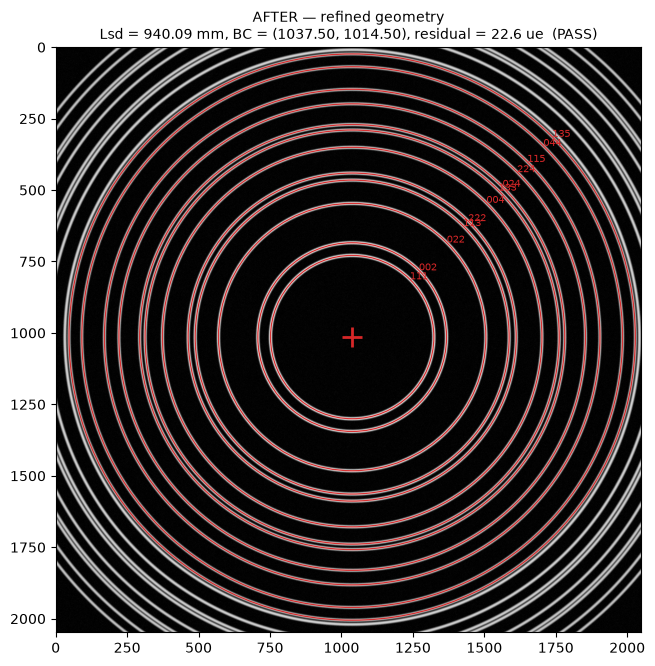

In [6]:
strain = res["strain"]
print(f"residual strain: {strain:.2f} ue")
if strain < 100:
    print("  PASS — under the 100 ue rule.")
else:
    print("  *** FAIL — do NOT use these parameters downstream. ***")
    print("  Check, in this order:")
    print("    1. pixel size, wavelength, calibrant lattice parameter")
    print("    2. image transform (is the frame flipped relative to MIDAS?)")
    print("    3. detector binning")
    print("    4. did you pass a BC_guess? (see section 3)")
    print("  Then look at the overlay below: it says WHICH of these is wrong.")

ref_rings = ceo2_like_radii(res["Lsd"], PIXEL_UM, WAVELENGTH_A)
ring_overlay(frame, res["BC_y"], res["BC_z"], [r for r, _ in ref_rings],
             f"AFTER — refined geometry\n"
             f"Lsd = {res['Lsd']/1000:.2f} mm, BC = ({res['BC_y']:.2f}, "
             f"{res['BC_z']:.2f}), residual = {strain:.1f} ue"
             f"  ({'PASS' if strain < 100 else 'FAIL'})",
             OUT_DIR / "after.png",
             labels=["".join(map(str, h)) for _, h in ref_rings])

In [7]:
# In demo mode the truth is known, so the calibration can be SCORED.
if truth is not None:
    print(f"{'':12} {'recovered':>14} {'planted':>14} {'error':>12}")
    print(f"{'Lsd (um)':12} {res['Lsd']:>14.1f} {truth['lsd_um']:>14.1f} "
          f"{res['Lsd']-truth['lsd_um']:>12.2f}")
    print(f"{'BC_y (px)':12} {res['BC_y']:>14.3f} {truth['bc_y_px']:>14.3f} "
          f"{res['BC_y']-truth['bc_y_px']:>12.3f}")
    print(f"{'BC_z (px)':12} {res['BC_z']:>14.3f} {truth['bc_z_px']:>14.3f} "
          f"{res['BC_z']-truth['bc_z_px']:>12.3f}")
    ppm = 1e6*abs(res['Lsd']-truth['lsd_um'])/truth['lsd_um']
    print(f"\nLsd recovered to {ppm:.1f} ppm; beam centre to "
          f"{max(abs(res['BC_y']-truth['bc_y_px']), abs(res['BC_z']-truth['bc_z_px'])):.3f} px")

                  recovered        planted        error
Lsd (um)           940085.0       940086.0        -0.99
BC_y (px)          1037.499       1037.500       -0.001
BC_z (px)          1014.497       1014.500       -0.003

Lsd recovered to 1.1 ppm; beam centre to 0.003 px


## 6 · Reference standard — a real single-detector calibration

The demo above is synthetic, so its rings are exactly the model. To show what
**real** data does, the same procedure was run on an archived CeO₂ exposure
from a single 2048×2048 area detector at a synchrotron beamline — anonymised,
with a previously published fit to compare against:

| | this procedure | archived reference | difference |
|---|---|---|---|
| Lsd | 940 055.3 µm | 940 086.1 | −30.8 µm (**33 ppm**) |
| BC_y | 1024.741 px | 1024.726 | **0.015 px** |
| BC_z | 994.345 px | 994.340 | **0.005 px** |
| residual strain | **47.0 µε** | 18.97 µε | both PASS |

Beam centre to a hundredth of a pixel, distance to 33 ppm, on real data with
real tilts and real distortion.

The gap in residual strain (47 vs 19) is explained: `calibrate()` seeds
`tx = 0` and never refines it — `tx` is absent from its `Refine` set — whereas
the archived fit carries `tx = −0.0804°`. If your setup has a significant
`tx`, this pipeline cannot currently recover it.

## 7 · Hand the geometry to the analysis

`DTGeometry` is what notebook `01` consumes. Everything below is written to
`calibration.json` so you never retype a number — retyping is how a digit gets
dropped and a whole dataset goes quietly wrong.

In [8]:
from midas_dt import DTGeometry

ny, nz = frame.shape[1], frame.shape[0]
rho_d_um = float(np.hypot(max(res["BC_y"], ny - res["BC_y"]),
                          max(res["BC_z"], nz - res["BC_z"])) * PIXEL_UM)

geo = DTGeometry(
    lsd_um=res["Lsd"], bc_y_px=res["BC_y"], bc_z_px=res["BC_z"],
    px_um=PIXEL_UM, n_pixels_y=ny, n_pixels_z=nz,
    wavelength_a=WAVELENGTH_A,
    tx_deg=res["tx"], ty_deg=res["ty"], tz_deg=res["tz"],
    distortion=res.get("distortion", {}), rho_d_um=rho_d_um,
)
print(geo.describe())
print(f"beam energy {geo.energy_kev:.3f} keV")

payload = dict(
    lsd_um=geo.lsd_um, bc_y_px=geo.bc_y_px, bc_z_px=geo.bc_z_px,
    px_um=geo.px_um, n_pixels_y=ny, n_pixels_z=nz,
    wavelength_a=geo.wavelength_a, tx_deg=geo.tx_deg, ty_deg=geo.ty_deg,
    tz_deg=geo.tz_deg, rho_d_um=geo.rho_d_um,
    distortion=res.get("distortion", {}),
    residual_strain_ue=strain, calibrant=CALIBRANT,
)
(OUT_DIR / "calibration.json").write_text(json.dumps(payload, indent=2))
print(f"\nwrote {OUT_DIR / 'calibration.json'}")
print("\nIn notebook 01, replace the calibration block in section 1 with:\n")
print("    import json")
print(f"    cal = json.load(open('{OUT_DIR}/calibration.json'))")
print("    LSD_UM        = cal['lsd_um']")
print("    BEAM_CENTRE_Y = cal['bc_y_px']")
print("    BEAM_CENTRE_Z = cal['bc_z_px']")
print("    PIXEL_UM      = cal['px_um']")
print("    WAVELENGTH_A  = cal['wavelength_a']")

Lsd 940085.0 um, BC (1037.499, 1014.497) px, px 200 um, 2048x2048, lambda 0.189714 A = 65.35 keV, tilts (0, 0.00374039, 0.0027941) deg
beam energy 65.353 keV

wrote calibration_output/calibration.json

In notebook 01, replace the calibration block in section 1 with:

    import json
    cal = json.load(open('calibration_output/calibration.json'))
    LSD_UM        = cal['lsd_um']
    BEAM_CENTRE_Y = cal['bc_y_px']
    BEAM_CENTRE_Z = cal['bc_z_px']
    PIXEL_UM      = cal['px_um']
    WAVELENGTH_A  = cal['wavelength_a']


## When it fails — what the overlay tells you

Always look at the ring overlay. A strain number says a calibration failed; the
picture says *what* failed.

| what you see | what it means |
|---|---|
| circles concentric but all too big or too small | **Lsd** wrong (or λ — the two trade off almost exactly at small angle) |
| circles not concentric with the rings | **beam centre** wrong |
| rings elliptical, circles round | **tilt** not refined, or too large for the model |
| rings sheared or mirrored | **image transform** wrong — MIDAS's frame orientation is not your detector's |
| circles match inner rings, drift outward | **distortion** not refined |
| predicted rings where there is no intensity | wrong **calibrant** or wrong lattice parameter |
| barely moved from the seed | the fit did not converge — did you pass a `BC_guess`? |

If the residual is above ~1000 µε, it is a constant, not the optimiser. Check
pixel size, wavelength, lattice parameter and image transform before anything
else.

### Next

`01_dt_recon_walkthrough.ipynb` — load `calibration.json` in its section 1 and
run the diffraction-tomography analysis.